# ASSIGNMENT 1: TRIP GENERATION
------------

**Jaime Alejandro Garcia**

**Fall - 2026**

**Class  CME 508 Urban Travel Forecasting**

---------------------------
This assignment corresponds to the second task of the course “CME 508 Urban Travel Forecasting”; it focuses on the study and practical application of trip distribution modeling within a transportation modeling framework. Additionally, the opportunity will be taken to advance the work using Python, allowing for a comparison with the development carried out in Excel, and the current material used in the course.

---------------
**Objectives of this report**

The assignment examines trip distribution modeling using three complementary approaches:

1. Developing and applying the bi-propositional updating approach, first in manual steps and later all the algorithm in one single run.
2. Developing and using the gravity approach, applying the impedance function, and comparing the results with the bi-propositional model.
3. Calculating and comparing the multiple goodness of fit approaches and commenting on their results

## Question 1
------------

Table 3 contains projected future year (2010) morning peak-period work trip ends for this system. Use the biproportional updating procedure to project the corresponding the future year trip matrix, given the base year matrix provided in Table 1. Stop when the maximum row or column sum error is 5% or less. In your answer show the results from your first, second to last, and last iterations. Also describe the computational procedure used to do these calculations in sufficient detail for the reader to understand how your answer was generated. 

-------------


In [59]:
#For most of this assignment, we will use the “numpy” and “pandas” libraries to create the matrix; for larger matrices, we might load them from a separate file.
import numpy as np
import pandas as pd

In [60]:
zones = [1, 2, 3, 4, 5]

od_base = pd.DataFrame(
    [
        [24.6, 1.0, 1.0, 2.7, 0.9],
        [24.1, 6.6, 3.8, 3.3, 1.2],
        [18.2, 4.2, 13.2, 4.3, 1.1],
        [28.5, 1.3, 2.5, 10.7, 3.4],
        [9.1, 0.7, 1.2, 3.4, 4.9],
    ],
    index=zones,
    columns=zones
)

od_base

,1,2,3,4,5
1,24.6,1.0,1.0,2.7,0.9
2,24.1,6.6,3.8,3.3,1.2
3,18.2,4.2,13.2,4.3,1.1
4,28.5,1.3,2.5,10.7,3.4
5,9.1,0.7,1.2,3.4,4.9


We create the trip matrix in pandas, as well as the target vectors. For the current vector, we calculate from the trip matrix. 

In [61]:
origins_target = pd.Series(
    [35, 44, 46, 51, 22],
    index=zones,
    name="Origins"
)

destinations_target = pd.Series(
    [114, 16, 22, 30, 16],
    index=zones,
    name="Destinations"
)

In [62]:
T = od_base.to_numpy(dtype=float)

O_target = origins_target.to_numpy(dtype=float)
D_target = destinations_target.to_numpy(dtype=float)

In [63]:
O_current = T.sum(axis=1)
O_current

array([30.2, 39. , 41. , 46.4, 19.3])

### Iteration 1.
----

First, we will perform a manual 1-iteration, and later it will be calculated in a single run.

--------

First, we will balance the matrix by origins, then we will calculate a row factor and balance the matrix.

In [64]:
row_factor = O_target/O_current
row_factor

array([1.1589404 , 1.12820513, 1.12195122, 1.09913793, 1.13989637])

In [65]:
T_row_balanced = T * row_factor[:, None]
T_row_balanced

array([[28.50993377,  1.1589404 ,  1.1589404 ,  3.12913907,  1.04304636],
       [27.18974359,  7.44615385,  4.28717949,  3.72307692,  1.35384615],
       [20.4195122 ,  4.71219512, 14.8097561 ,  4.82439024,  1.23414634],
       [31.32543103,  1.42887931,  2.74784483, 11.76077586,  3.73706897],
       [10.37305699,  0.79792746,  1.36787565,  3.87564767,  5.58549223]])

In [66]:
D_current = T_row_balanced.sum(axis=0)
D_current

array([117.81767759,  15.54409614,  24.37159646,  27.31302977,
        12.95360005])

Now, we will balance the matrix by calculating the column factor and the adjusted matrix.

In [67]:
column_factor = D_target/D_current
column_factor

array([0.96759673, 1.02932971, 0.90269015, 1.09837686, 1.23517786])

In [68]:
T_column_balanced = T * column_factor

And the last step in the first iteration will be to check for errors.

In [69]:
O_check = T_column_balanced.sum(axis=1)
D_check = T_column_balanced.sum(axis=0)

r_check = O_target / O_check
c_check = D_target / D_check

origin_error = np.round((np.abs(1 - r_check)*100),3)
destination_error = np.round((np.abs(1 - c_check)*100),3)

print(f"The calculation of the errors for each one of the elements of the origin vector is{origin_error} en %")
print(f"The calculation of the errors for each one of the elements of the destination vector is {destination_error} en %")

The calculation of the errors for each one of the elements of the origin vector is[17.402 13.843 15.2    8.226  7.866] en %
The calculation of the errors for each one of the elements of the destination vector is [12.744 12.638 12.312 11.939 12.64 ] en %


In [70]:
converged = (
    np.all(origin_error <= 5.0)
    and
    np.all(destination_error <= 5.0)
)
converged

np.False_

Since all vector values are above 5%, we need to iterate again. Now, we will do it in a single line to see the algorithm 

### Iteracion 2

In [71]:
T_New =T_column_balanced

In [72]:
T = T_New.copy()

O_current = T.sum(axis=1)
r = O_target / O_current

T = T * r[:, None]

D_current = T.sum(axis=0)
c = D_target / D_current

T = T * c

O_check = T.sum(axis=1)
D_check = T.sum(axis=0)

r_check = O_target / O_check
c_check = D_target / D_check

origin_error = np.round((np.abs(1 - r_check)*100),3)
destination_error = np.round((np.abs(1 - c_check)*100),3)

converged = (
    np.all(origin_error <= 5.0)
    and
    np.all(destination_error <= 5))

In [73]:
print(f"The trip matrix was calculated after the iteration is the next: \n {T}")
print(f"The factor vector calculated for origins is the next \n {r_check} in %")
print(f"The factor vector calculated for destinations is the next \n {c_check} in %")
print ("Then the result, the Errors of both origins/destinations are the next:\n ")
print(f"Calculation origins errors: {origin_error} in %")
print(f"Calculation destinations errors: {destination_error} in %")

T_New = T

The trip matrix was calculated after the iteration is the next: 
 [[27.9151717   1.19736283  1.04541036  3.50544969  1.33589924]
 [26.51880931  7.66304703  3.85214104  4.15456632  1.72720633]
 [20.26531932  4.93459974 13.54059035  5.47804123  1.60214104]
 [29.81312065  1.4349161   2.40926289 12.80622515  4.65229764]
 [ 9.48757902  0.7700743   1.15259535  4.05571761  6.68245574]]
The factor vector calculated for origins is the next 
 [1.00002018 1.00191799 1.00391326 0.99773412 0.99329875] in %
The factor vector calculated for destinations is the next 
 [1. 1. 1. 1. 1.] in %
Then the result, the Errors of both origins/destinations are the next:
 
Calculation origins errors: [0.002 0.192 0.391 0.227 0.67 ] in %
Calculation destinations errors: [0. 0. 0. 0. 0.] in %


### Iteration 3
----

Finally, we will do a last iteration, but in the second iteration, the matrix had converged.

In [74]:
T = T_New.copy()

O_current = T.sum(axis=1)
r = O_target / O_current

T = T * r[:, None]

D_current = T.sum(axis=0)
c = D_target / D_current

T = T * c

O_check = T.sum(axis=1)
D_check = T.sum(axis=0)

r_check = O_target / O_check
c_check = D_target / D_check

origin_error = np.round((np.abs(1 - r_check)*100),3)
destination_error = np.round((np.abs(1 - c_check)*100),3)

converged = (
    np.all(origin_error <= 5.0)
    and
    np.all(destination_error <= 5))

In [75]:
print(f"The trip matrix was calculated after the iteration is the next: \n {T}")
print(f"The factor vector calculated for origins is the next \n {r_check} in %")
print(f"The factor vector calculated for destinations is the next \n {c_check} in %")
print ("Then the result, the Errors of both origins/destinations are the next:\n ")
print(f"Calculation origins errors: {origin_error} in %")
print(f"Calculation destinations errors: {destination_error} in %")

T_New = T

The trip matrix was calculated after the iteration is the next: 
 [[27.91583341  1.19547272  1.04319265  3.50864541  1.33975396]
 [26.56976582  7.66547016  3.85126417  4.16624541  1.73547747]
 [20.34469456  4.94599023 13.5644674   5.50438073  1.61301914]
 [29.74567255  1.42937592  2.39865601 12.78859797  4.65505588]
 [ 9.42403366  0.76369097  1.14241977  4.03213048  6.65669356]]
The factor vector calculated for origins is the next 
 [0.9999172  1.00026773 1.00059705 0.99965976 0.99913854] in %
The factor vector calculated for destinations is the next 
 [1. 1. 1. 1. 1.] in %
Then the result, the Errors of both origins/destinations are the next:
 
Calculation origins errors: [0.008 0.027 0.06  0.034 0.086] in %
Calculation destinations errors: [0. 0. 0. 0. 0.] in %


## Question 2
-------------

A conventional gravity model (as discussed in class) has been estimated using the data presented in Tables 1 and 2. The impedance function for this gravity model is:

$$
f_{ij} = e^{-0.064a_{ij}}
$$

where $a_{ij}$ is the auto travel time from zone $i$ to zone $j$.

a) Use this gravity model with the data from Tables 2 and 3 to generate a second estimate of the future trip table. Iterate until the matrix is balanced to within \(\pm 5\%\) for every column sum.

In your answer show the results from your first, second to last, and last iterations. Also describe the computational procedure used to do these calculations in sufficient detail for the reader to understand how your answer was generated.

b) Compare your results with those obtained in Question 1. Which set of results (if either) is likely to be more reliable? Explain.

-----

At this point, we will apply the gravity model, then upload the matrix and calculations manually, or upload them as files. 

In [37]:
zones = [1, 2, 3, 4, 5]
O_target = np.array([35, 44, 46, 51, 22], dtype=float)
D_target = np.array([114, 16, 22, 30, 16], dtype=float)

In [38]:
travel_time = np.array([
    [8.4, 15.8, 30.2, 16.8, 33.6],
    [13.2, 8.4, 12.0, 25.2, 36.0],
    [25.2, 10.0, 8.4, 14.4, 29.0],
    [14.0, 21.0, 12.0, 8.4, 13.2],
    [28.0, 30.0, 24.2, 11.0, 8.4]
], dtype=float)

Since we have an impedance function, we can calculate the total impedance, which we will call friction, and which will be the base for further calculations.

In [39]:
friction = np.exp(-0.064 * travel_time)
friction

array([[0.58414853, 0.36378218, 0.14474235, 0.3412295 , 0.11643757],
       [0.42964328, 0.58414853, 0.46394002, 0.19932871, 0.09985861],
       [0.19932871, 0.52729242, 0.58414853, 0.39788192, 0.15629657],
       [0.4081992 , 0.26080038, 0.46394002, 0.58414853, 0.42964328],
       [0.16662658, 0.14660696, 0.21250282, 0.49460293, 0.58414853]])

### Iteration 1
------

Now, we will do our first iteration step by step. First, we will calculate the estimated weights 
$$
W_{ij} = D_j^{*} f_{ij}
$$

In [76]:
D_star = D_target.copy()
weights = friction * D_star
weights

array([[66.59293217,  5.82051486,  3.18433174, 10.23688508,  1.86300117],
       [48.97933372,  9.34637645, 10.20668046,  5.97986135,  1.59773775],
       [22.72347312,  8.43667878, 12.85126761, 11.93645761,  2.50074509],
       [46.53470826,  4.17280605, 10.20668046, 17.52445584,  6.87429245],
       [18.99543046,  2.34571139,  4.67506213, 14.8380879 ,  9.34637645]])

In [77]:
denominator = weights.sum(axis=1)
denominator

array([87.69766503, 76.10998973, 58.44862222, 85.31294306, 50.20066834])

Now, with this, we can calculate our new trip matrix using gravity calculations.
$$
T_{ij} = O_i \frac{D_j^{*} f_{ij}}{\sum_j D_j^{*} f_{ij}}
$$


In [42]:
T = O_target[:, None] * weights / denominator[:, None]
T

array([[26.57713435,  2.32295832,  1.27086178,  4.08552471,  0.74352083],
       [28.31547726,  5.4032403 ,  5.90059126,  3.45702187,  0.9236693 ],
       [17.88373659,  6.63980107, 10.11415304,  9.39418295,  1.96812636],
       [27.8184064 ,  2.49449967,  6.10154433, 10.47610381,  4.10944579],
       [ 8.32457981,  1.02798732,  2.04880473,  6.50266111,  4.09596702]])

In [43]:
O_current = T.sum(axis=1)
D_current = T.sum(axis=0)

With this, we can calculate the errors and evaluate whether it meets the requirements or if another iteration is needed.

In [44]:
R = D_target / D_current
error = np.round((np.abs(1 - R)*100),3)
np.all(error <= 5.0)
error

array([ 4.665, 10.557, 13.508, 11.545, 35.127])

In [ ]:
print(f"The trip matrix was calculated after the iteration is the next: \n {T}")
print(f"The factor R for verification is \n {R} in %")
print(f"Calculation errors: {error} in %")

The trip matrix was calculated after the iteration is the next: 
 [[27.91583341  1.19547272  1.04319265  3.50864541  1.33975396]
 [26.56976582  7.66547016  3.85126417  4.16624541  1.73547747]
 [20.34469456  4.94599023 13.5644674   5.50438073  1.61301914]
 [29.74567255  1.42937592  2.39865601 12.78859797  4.65505588]
 [ 9.42403366  0.76369097  1.14241977  4.03213048  6.65669356]]
The factor R for verification is 
 [1.00008339 0.99946694 0.99948447 1.00006998 1.00051749] in %
Calculation errors: [0.008 0.053 0.052 0.007 0.052] in %


### Iteration 2
------

We are going to perform a second iteration, but we will do it in a single run.

In [80]:
D_star = D_star*R
weights = friction * D_star

denominator = weights.sum(axis=1)

T = O_target[:, None] * weights / denominator[:, None]

O_current = T.sum(axis=1)
D_current = T.sum(axis=0)

R = D_target / D_current
error = np.round((np.abs(1 - R)*100),3)
np.all(error <= 5.0)

np.False_

In [81]:
print(f"The trip matrix was calculated after the iteration is the next: \n {T}")
print(f"The factor R for verification is \n {R} in %")
print(f"Calculation errors: {error} in %")

The trip matrix was calculated after the iteration is the next: 
 [[26.57859617  2.32165413  1.27017057  4.08569464  0.74388449]
 [28.31966707  5.40070875  5.89793017  3.45748704  0.92420697]
 [17.88740019  6.63706766 10.11016672  9.39598142  1.96938401]
 [27.82034201  2.49313552  6.0983146  10.47669225  4.11151562]
 [ 8.3246441   1.0273616   2.04759358  6.50262413  4.09777658]]
The factor R for verification is 
 [1.04653741 0.89485821 0.86531813 0.88447361 1.35057937] in %
Calculation errors: [ 4.654 10.514 13.468 11.553 35.058] in %


### Iteration 3
Finally, we're going to do one last iteration again with the calculations in a single run

In [82]:
D_star = D_star*R
weights = friction * D_star

denominator = weights.sum(axis=1)

T = O_target[:, None] * weights / denominator[:, None]

O_current = T.sum(axis=1)
D_current = T.sum(axis=0)

R = D_target / D_current
error = np.round((np.abs(1 - R)*100),3)
np.all(error <= 5.0)

np.True_

In [83]:
print(f"The trip matrix was calculated after the iteration is the next: \n {T}")
print(f"The factor R for verification is \n {R} in %")
print(f"Calculation errors: {error} in %")

The trip matrix was calculated after the iteration is the next: 
 [[27.33862201  2.04193339  1.08025844  3.55173543  0.98745073]
 [29.71842762  4.8460502   5.11750591  3.0663969   1.25161937]
 [19.40408677  6.15632724  9.06828883  8.61426554  2.75703161]
 [28.8646984   2.21182067  5.23161079  9.1866859   5.50518423]
 [ 8.44749654  0.89142569  1.71801579  5.57674928  5.36631271]]
The factor R for verification is 
 [1.00199228 0.99086195 0.99029155 1.00013892 1.00834413] in %
Calculation errors: [0.199 0.914 0.971 0.014 0.834] in %


## Question 3
-------

Table 4 provides a predicted 2000 O-D trip table generated by the trip distribution model described in Question 2. Compute R2, χ2, MABSERR, and normalized φ statistics for the gravity model’s goodness of fit to the observed Table 1 trip matrix. Plot predicted and observed trip length frequency distributions. Comment on the model’s goodness of fit to observed data.

In this question, we will examine the goodness of fit and performance metrics, and comment on the observed values.

In [47]:
observed = np.array([
    [24.6, 1.0, 1.0, 2.7, 0.9],
    [24.1, 6.6, 3.8, 3.3, 1.2],
    [18.2, 4.2, 13.2, 4.3, 1.1],
    [28.5, 1.3, 2.5, 10.7, 3.4],
    [9.1, 0.7, 1.2, 3.4, 4.9]
], dtype=float)

predicted = np.array([
    [24.0819505661004, 1.693919590696,   1.01644950903738, 2.74022918487959, 0.667451149286626],
    [26.7087395954534, 4.1015844273944,  4.91279928380433, 2.4137215735343,  0.863155119813617],
    [17.8583518408786, 5.33587987559749, 8.91490281331451, 6.94380732034893, 1.94705814986051],
    [27.4414600188474, 1.98027854948974, 5.31274191342443, 7.64945152667874, 4.0160679915597],
    [8.10146231821282, 0.805112778181,   1.75997154134532, 4.6843329179711,  3.94912044428976]
], dtype=float)

### Calculo de $R2$
---------
Ahora vamos a realizar el calculo de el R2, para tal fin vamos a calcular cada parte y revisar el resultado


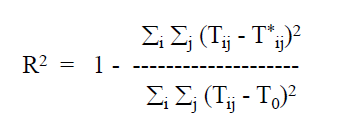

In [48]:
Numer= (observed-predicted)**2
Numer

array([[2.68375216e-01, 4.81524398e-01, 2.70586348e-04, 1.61838732e-03,
        5.40789680e-02],
       [6.80552228e+00, 6.24208037e+00, 1.23832225e+00, 7.85489449e-01,
        1.13464473e-01],
       [1.16723465e-01, 1.29022309e+00, 1.83620579e+01, 6.98971715e+00,
        7.17507509e-01],
       [1.12050689e+00, 4.62778905e-01, 7.91151707e+00, 9.30584599e+00,
        3.79539770e-01],
       [9.97077502e-01, 1.10486961e-02, 3.13568127e-01, 1.64951104e+00,
        9.04171929e-01]])

In [49]:
Numer.sum()

np.float64(66.5225414122578)

In [50]:
T0 = observed.sum() / observed.size
denom = (observed-T0)**2
denom

array([[3.08494096e+02, 3.64332960e+01, 3.64332960e+01, 1.88008960e+01,
        3.76504960e+01],
       [2.91180096e+02, 1.90096000e-01, 1.04716960e+01, 1.39576960e+01,
        3.40588960e+01],
       [1.24634896e+02, 8.04289600e+00, 3.79948960e+01, 7.48569600e+00,
        3.52360960e+01],
       [4.60703296e+02, 3.29016960e+01, 2.05752960e+01, 1.34248960e+01,
        1.32204960e+01],
       [4.26009600e+00, 4.01448960e+01, 3.40588960e+01, 1.32204960e+01,
        4.56249600e+00]])

In [51]:
R2= 1- (Numer.sum()/denom.sum())
R2

np.float64(0.9593913591799261)

in conclusion, this is a highly relevant value with great practical interpretability; in this case, the value of 95.93 allows us to observe that the model likely performs well when comparing observed and predicted values, as it is close to 1.

### Calculo Chi
------
In the second step, we will calculate the chi-square statistic, which is widely used to compare two distributions or two elements; in this way, we calculate each of the elements.

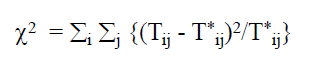

In [52]:
chi2 = (((observed-predicted)**2)/predicted)
chi2

array([[1.11442474e-02, 2.84266385e-01, 2.66207367e-04, 5.90602905e-04,
        8.10231101e-02],
       [2.54805071e-01, 1.52187051e+00, 2.52060419e-01, 3.25426701e-01,
        1.31453166e-01],
       [6.53607151e-03, 2.41801375e-01, 2.05970365e+00, 1.00661162e+00,
        3.68508516e-01],
       [4.08326267e-02, 2.33693843e-01, 1.48915893e+00, 1.21653768e+00,
        9.45053149e-02],
       [1.23073769e-01, 1.37231658e-02, 1.78166589e-01, 3.52133606e-01,
        2.28955268e-01]])

In [53]:
chi2 = chi2.sum()
chi2

np.float64(10.516848446835159)

Given that the ideal value is 0, this figure reveals differences between the estimated model and the perfectly fitted value. However, this parameter cannot be analyzed in isolation but must be considered alongside other parameters. Nevertheless, it demonstrates that there are indeed cases with differing values.

### Calculo MABSERR
-----

This is one of the most interesting indicators because it is quite intuitive, as it allows us to determine the model's average potential estimation error; we will calculate it at each step.

In [54]:
Part = abs(observed-predicted)
Part

array([[0.51804943, 0.69391959, 0.01644951, 0.04022918, 0.23254885],
       [2.6087396 , 2.49841557, 1.11279928, 0.88627843, 0.33684488],
       [0.34164816, 1.13587988, 4.28509719, 2.64380732, 0.84705815],
       [1.05853998, 0.68027855, 2.81274191, 3.05054847, 0.61606799],
       [0.99853768, 0.10511278, 0.55997154, 1.28433292, 0.95087956]])

In [55]:
Part.size**2

625

In [56]:
MABSERR = Part.sum() /Part.size
MABSERR

np.float64(1.2125910561319098)

In conclusion, this value is highly interesting, as it shows that, on average, the model errs by approximately 1,213 trips for each O-D pair, regardless of whether the error is an overestimation or an underestimation. This value should be compared against the cell values; for instance, it may be very significant for low values, whereas for cells with large numbers, it may be marginal.

### Normalized $\phi$
------

Normalized $\phi$ measures the weighted proportional discrepancy between observed and predicted O-D flows, where values closer to 0 indicate a better fit.

In [57]:
phi = (observed/ observed.sum())*(abs(np.log(observed/predicted)))
phi

array([[2.97658912e-03, 2.99627702e-03, 9.27554376e-05, 2.27017781e-04,
        1.52948098e-03],
       [1.40817159e-02, 1.78487527e-02, 5.54862285e-03, 5.86744673e-03,
        2.24774815e-03],
       [1.96074788e-03, 5.71546867e-03, 2.94536710e-02, 1.17152438e-02,
        3.57083771e-03],
       [6.13245439e-03, 3.11049021e-03, 1.07137200e-02, 2.04151494e-02,
        3.21884477e-03],
       [6.01302728e-03, 5.56744859e-04, 2.61268504e-03, 6.19399373e-03,
        6.00987711e-03]])

In [58]:
norm_phi = phi.sum()
norm_phi

np.float64(0.17080936257165513)

The normalized $\phi$ statistic is approximately 0.171. A value of zero would indicate a perfect match between the observed and predicted trip matrices, while larger values indicate greater proportional discrepancies. Therefore, the result indicates that some proportional differences remain between the observed and predicted distributions and should be interpreted together with \(R^2\), \(\chi^2\), MABSERR, and the trip-length frequency distributions.

## Question 4
---

Suppose a sixth zone has been developed between the base and forecast years. What options exist for predicting flows to/from this new zone? Which would you choose? Explain.

**Answer**

In this hypothetical scenario involving the creation of a new zone, there are no observed base-year trips to or from this new 6th zone; however, future conditions are known, and travel impedances between the new zone and the existing zones can be calculated to estimate the potential difficulty of accessing it.

Consequently, a methodological approach that does not rely on an observed base-year O-D pattern regarding the new zone is required to estimate the predicted trips. Given this, applying a bi-proportional methodology would not be suitable, as there are no base-year rows or columns for Zone 6. However, with a gravity-based methodology, if the generation and attraction vectors for the future condition, as well as the impedances, are known, it is possible to estimate trips to and from the new zone.

Another possible option would be to estimate a trip pattern from a similar existing zone, although this would require additional assumptions. At the same time, factors such as whether the zone primarily generates or attracts trips must be considered in order to estimate trip generation and projected travel volumes for the new zone. Once the new zone has been characterized based on these assumptions, any distribution model could be applied.

In conclusion, in the hypothetical case of a new zone, applying a gravity-based methodology to the trip distribution model is appropriate because it can generate O-D flows without requiring an observed base-year trip pattern for Zone 6.
